Importing libraries/frameworks

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

Load Dataset

In [35]:
df = pd.read_csv("Airbnb_Open_Data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (102599, 26)


/tmp/ipykernel_750/2278598554.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Data Overview

In [36]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


Clean Price and Service Fee

In [37]:
df["price"] = df["price"].replace(r"[\$,]", "", regex=True).astype(float)
df["service fee"] = df["service fee"].replace(r"[\$,]", "", regex=True).astype(float)

df[["price", "service fee"]].head()

,price,service fee
0,966.0,193.0
1,142.0,28.0
2,620.0,124.0
3,368.0,74.0
4,204.0,41.0


Drop Unnecessary Columns

In [38]:
cols_to_drop = [
    "id",
    "NAME",
    "host id",
    "host name",
    "lat",
    "long",
    "country",
    "country code",
    "last review",
    "house_rules",
    "license",
    "neighbourhood"
]

df = df.drop(cols_to_drop, axis=1)

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (102599, 14)


Handle Missing Values

In [39]:
df.fillna(0, inplace=True)

print("Missing values remaining:")
print(df.isnull().sum().sum())

Missing values remaining:
0


Reduce Dataset Size (Efficiency)

In [40]:
df = df.sample(25000, random_state=42)

print("Shape after sampling:", df.shape)

Shape after sampling: (25000, 14)


Encode Categorical Columns Properly

In [41]:
categorical_cols = [
    "host_identity_verified",
    "neighbourhood group",
    "instant_bookable",
    "cancellation_policy",
    "room type"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (25000, 23)


Log Transform Target and Split Features

In [42]:
y = np.log1p(df["price"])
X = df.drop("price", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (20000, 22)
Test set shape: (5000, 22)


Linear Regression Baseline

In [43]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 0.21792067144665653
RMSE: 0.43534663253228395
R2: 0.709036154561377


Random Forest (Improved Version)

In [44]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 0.04396075760727504
RMSE: 0.38711467091875273
R2: 0.7699364006772682


Model Comparison Table

In [45]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.217921,0.435347,0.709036
1,Random Forest,0.043961,0.387115,0.769936


Converting Back to Actual Prices

In [46]:
real_pred = np.expm1(rf_pred)
real_actual = np.expm1(y_test)

Feature Importance Plot

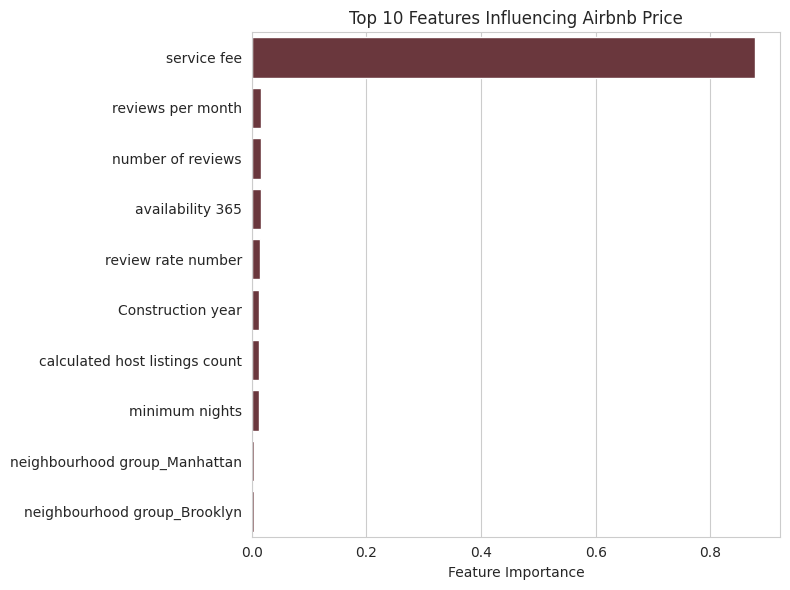

In [48]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    color='#722F37'
)

plt.title("Top 10 Features Influencing Airbnb Price")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

Actual vs Predicted Plot

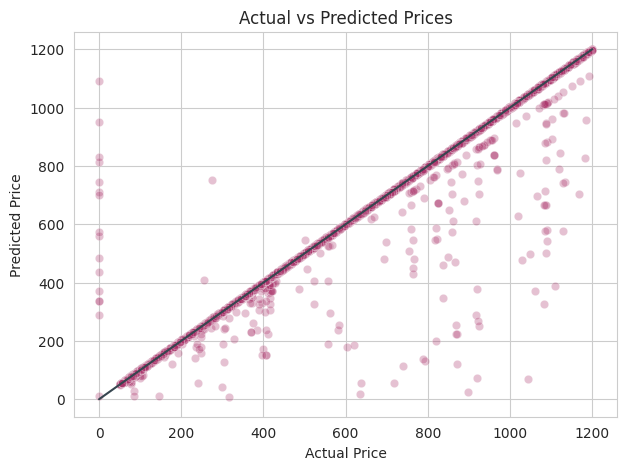

In [52]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=real_actual, y=real_pred, alpha=0.3, color="#AA336A")

plt.plot(
    [real_actual.min(), real_actual.max()],
    [real_actual.min(), real_actual.max()],
    color="#36454F"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

Residual Plot

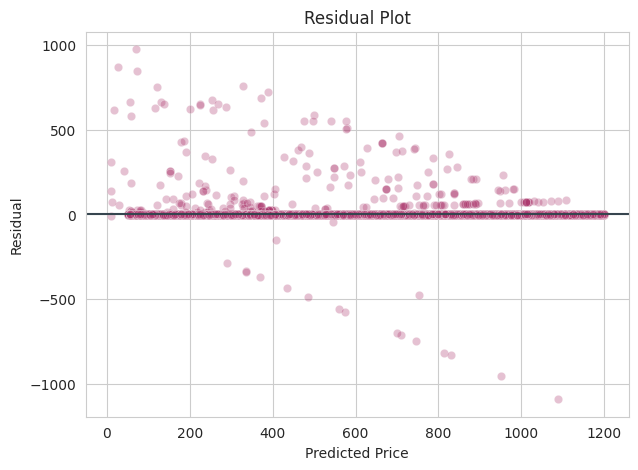

In [53]:
residuals = real_actual - real_pred

plt.figure(figsize=(7,5))
sns.scatterplot(x=real_pred, y=residuals, alpha=0.3, color="#AA336A")
plt.axhline(0, color="#36454F")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Hyperparameter Tuning

In [54]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Best CV Score: 0.8308448705056944


Pricing Prediction Function

In [55]:
best_model = grid.best_estimator_

def predict_price(input_data):
    input_df = pd.DataFrame([input_data])
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    predicted_log_price = best_model.predict(input_df)
    predicted_price = np.expm1(predicted_log_price)

    return round(predicted_price[0], 2)

Revenue Simulation

In [56]:
def revenue_simulation(base_price, occupancy_rate):
    revenue = base_price * occupancy_rate
    increased_price = base_price * 1.05
    new_revenue = increased_price * (occupancy_rate * 0.97)

    return {
        "Current Revenue": round(revenue, 2),
        "New Revenue (5% increase)": round(new_revenue, 2)
    }